In [23]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


PosixPath('/mnt/pdata/Classical_Conditioning/figures')

In [2]:
# --------------------------------------------------
# Inspect phase and anchor names
# --------------------------------------------------

print("Phases:")
print(encoder_epoch_df["phase"].value_counts())

anchor_col = "anchor_name" if "anchor_name" in encoder_epoch_df.columns else "epoch_name"
print("\nUsing anchor column:", anchor_col)

print("\nAnchors by phase:")
display(
    encoder_epoch_df
    .groupby(["phase", anchor_col])
    .size()
    .reset_index(name="n")
    .sort_values(["phase", anchor_col])
)

print("\nWindow positions:")
print(encoder_epoch_df["window_position"].value_counts())

Phases:
phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64

Using anchor column: anchor_name

Anchors by phase:


,phase,anchor_name,n
0,air_training,air_off,7060
1,air_training,air_off_mid,7033
2,air_training,air_on,7067
3,air_training,air_on_mid,7069
4,air_training,pseudo_tone_off,7070
5,air_training,pseudo_tone_on,7063
6,habituation,LED_off,6373
7,habituation,LED_off_mid,6327
8,habituation,LED_on,6390
9,habituation,LED_on_mid,6386



Window positions:
window_position
pre     50952
post    50909
Name: count, dtype: int64


In [3]:
# --------------------------------------------------
# Choose tone-air phase
# --------------------------------------------------

tone_phase_candidates = [
    p for p in encoder_epoch_df["phase"].dropna().unique()
    if "tone" in str(p).lower()
]

print("Tone phase candidates:", tone_phase_candidates)

tone_air_phase = tone_phase_candidates[0]
print("Using tone-air phase:", tone_air_phase)

Tone phase candidates: ['tone_air_training']
Using tone-air phase: tone_air_training


In [4]:
# --------------------------------------------------
# Prepare tone-air window dataframe
# --------------------------------------------------

tone_air_anchors = [
    "tone_on",
    "air_on",
    "tone_off",
    "air_on_mid",
    "air_off",
    "air_off_mid",
]

tone_air_epoch_map = {
    ("tone_on", "pre"): "pre_tone_on",
    ("tone_on", "post"): "post_tone_on",

    ("air_on", "pre"): "pre_air_on",
    ("air_on", "post"): "post_air_on",

    ("tone_off", "pre"): "pre_tone_off",
    ("tone_off", "post"): "post_tone_off",

    ("air_on_mid", "pre"): "pre_air_on_mid",
    ("air_on_mid", "post"): "post_air_on_mid",

    ("air_off", "pre"): "pre_air_off",
    ("air_off", "post"): "post_air_off",

    ("air_off_mid", "pre"): "pre_air_off_mid",
    ("air_off_mid", "post"): "post_air_off_mid",
}

tone_air_cycle_order = [
    "pre_tone_on",
    "post_tone_on",
    "pre_air_on",
    "post_air_on",
    "pre_tone_off",
    "post_tone_off",
    "pre_air_on_mid",
    "post_air_on_mid",
    "pre_air_off",
    "post_air_off",
    "pre_air_off_mid",
    "post_air_off_mid",
    "pre_tone_on_next",
]


def prepare_tone_air_window_df(
    encoder_epoch_df,
    phase,
    anchors,
    anchor_col="anchor_name",
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
):
    """
    Prepare long-format tone-air training window dataframe.

    One row = one pre/post window around a tone-air anchor.
    """

    df = encoder_epoch_df.copy()

    df = df[
        (df["phase"] == phase) &
        (df[anchor_col].isin(anchors)) &
        (df["window_position"].isin(["pre", "post"]))
    ].copy()

    if require_good_session and "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if require_valid_window and "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    # biological epoch labels
    df["tone_air_epoch_label"] = [
        tone_air_epoch_map.get((a, w), np.nan)
        for a, w in zip(df[anchor_col], df["window_position"])
    ]

    df = df[df["tone_air_epoch_label"].notna()].copy()

    # IDs
    df["animal_day"] = (
        df["animal"].astype(str) + ":" +
        df["date"].astype(str)
    )

    # Session time
    if "session_time_min" not in df.columns:
        if "anchor_session_time_min" in df.columns:
            df["session_time_min"] = df["anchor_session_time_min"]
        elif "anchor_time_s" in df.columns:
            df["session_time_min"] = df["anchor_time_s"] / 60.0
        elif "session_time_s" in df.columns:
            df["session_time_min"] = df["session_time_s"] / 60.0
        else:
            df["session_time_min"] = np.nan

    # Exposure session number
    if "phase_session_number" in df.columns:
        df["tone_air_session"] = df["phase_session_number"]
    elif "phase_day_number_good" in df.columns:
        df["tone_air_session"] = df["phase_day_number_good"]
    else:
        # Try merging from session_day_df
        merge_cols = [
            c for c in [
                "animal",
                "date",
                "phase",
                "phase_day_number_good",
                "phase_session_number",
            ]
            if c in session_day_df.columns
        ]

        sess_tmp = session_day_df[merge_cols].drop_duplicates().copy()

        df = df.merge(
            sess_tmp,
            on=[c for c in ["animal", "date", "phase"] if c in merge_cols],
            how="left",
            suffixes=("", "_sess")
        )

        if "phase_session_number" in df.columns:
            df["tone_air_session"] = df["phase_session_number"]
        elif "phase_day_number_good" in df.columns:
            df["tone_air_session"] = df["phase_day_number_good"]
        else:
            df["tone_air_session"] = np.nan

    return df.reset_index(drop=True)


tone_air_window_df = prepare_tone_air_window_df(
    encoder_epoch_df=encoder_epoch_df,
    phase=tone_air_phase,
    anchors=tone_air_anchors,
    anchor_col=anchor_col,
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
)

print(tone_air_window_df.shape)

display(
    tone_air_window_df["tone_air_epoch_label"]
    .value_counts()
    .reindex([x for x in tone_air_cycle_order if x != "pre_tone_on_next"])
)

(21154, 63)


tone_air_epoch_label
pre_tone_on         1766
post_tone_on        1766
pre_air_on          1766
post_air_on         1766
pre_tone_off        1766
post_tone_off       1765
pre_air_on_mid      1766
post_air_on_mid     1766
pre_air_off         1766
post_air_off        1759
pre_air_off_mid     1751
post_air_off_mid    1751
Name: count, dtype: int64

In [5]:
# --------------------------------------------------
# Build full tone-air cycle dataframe
# --------------------------------------------------

def make_tone_air_cycle_df(
    tone_air_window_df,
    trial_col="event_number",
    require_complete_cycles=True,
):
    """
    Build long-format full tone-air cycle dataframe.

    One cycle = trial N.

    Includes:
        all tone/air epochs from trial N
        plus pre_tone_on from trial N+1 as pre_tone_on_next
    """

    df = tone_air_window_df.copy()

    if trial_col not in df.columns:
        raise ValueError(f"{trial_col} not found in dataframe.")

    current_epochs = [
        "pre_tone_on",
        "post_tone_on",
        "pre_air_on",
        "post_air_on",
        "pre_tone_off",
        "post_tone_off",
        "pre_air_on_mid",
        "post_air_on_mid",
        "pre_air_off",
        "post_air_off",
        "pre_air_off_mid",
        "post_air_off_mid",
    ]

    # Current-trial epochs
    cur = df[df["tone_air_epoch_label"].isin(current_epochs)].copy()
    cur["cycle_trial"] = cur[trial_col].astype(int)
    cur["tone_air_cycle_epoch"] = cur["tone_air_epoch_label"]

    # Next pre-tone baseline:
    # pre_tone_on from trial N+1 becomes pre_tone_on_next for cycle N
    nxt = df[df["tone_air_epoch_label"] == "pre_tone_on"].copy()
    nxt["cycle_trial"] = nxt[trial_col].astype(int) - 1
    nxt["tone_air_cycle_epoch"] = "pre_tone_on_next"
    nxt = nxt[nxt["cycle_trial"] >= 1].copy()

    cycle_df = pd.concat([cur, nxt], ignore_index=True)

    # IDs
    cycle_df["animal_day"] = (
        cycle_df["animal"].astype(str) + ":" +
        cycle_df["date"].astype(str)
    )

    cycle_df["cycle_id"] = (
        cycle_df["animal"].astype(str) + ":" +
        cycle_df["date"].astype(str) + ":" +
        cycle_df["cycle_trial"].astype(str)
    )

    # Cycle-level time/session reference = pre_tone_on of that cycle
    cycle_info = (
        cycle_df[cycle_df["tone_air_cycle_epoch"] == "pre_tone_on"]
        [["animal", "date", "cycle_trial", "session_time_min", "tone_air_session"]]
        .drop_duplicates()
        .rename(columns={
            "session_time_min": "cycle_session_time_min",
            "tone_air_session": "cycle_tone_air_session",
        })
    )

    cycle_df = cycle_df.merge(
        cycle_info,
        on=["animal", "date", "cycle_trial"],
        how="left"
    )

    # Optional: keep only complete cycles
    if require_complete_cycles:
        counts = (
            cycle_df
            .groupby("cycle_id")["tone_air_cycle_epoch"]
            .nunique()
        )

        complete_cycle_ids = counts[counts == len(tone_air_cycle_order)].index

        cycle_df = cycle_df[
            cycle_df["cycle_id"].isin(complete_cycle_ids)
        ].copy()

    # Ordered categorical
    cycle_df["tone_air_cycle_epoch"] = pd.Categorical(
        cycle_df["tone_air_cycle_epoch"],
        categories=tone_air_cycle_order,
        ordered=True,
    )

    # Center predictors
    cycle_df["tone_air_session_c"] = (
        cycle_df["cycle_tone_air_session"] -
        cycle_df["cycle_tone_air_session"].mean()
    )

    cycle_df["cycle_session_10m_c"] = (
        cycle_df["cycle_session_time_min"] -
        cycle_df["cycle_session_time_min"].mean()
    ) / 10.0

    return cycle_df.reset_index(drop=True)


tone_air_cycle_df = make_tone_air_cycle_df(
    tone_air_window_df,
    trial_col="event_number",
    require_complete_cycles=True,
)

print(tone_air_cycle_df.shape)

display(
    tone_air_cycle_df["tone_air_cycle_epoch"]
    .value_counts()
    .sort_index()
)

(21762, 70)


tone_air_cycle_epoch
pre_tone_on         1674
post_tone_on        1674
pre_air_on          1674
post_air_on         1674
pre_tone_off        1674
post_tone_off       1674
pre_air_on_mid      1674
post_air_on_mid     1674
pre_air_off         1674
post_air_off        1674
pre_air_off_mid     1674
post_air_off_mid    1674
pre_tone_on_next    1674
Name: count, dtype: int64

In [6]:
# --------------------------------------------------
# Sanity checks
# --------------------------------------------------

print("Animals:", tone_air_cycle_df["animal"].nunique())
print("Animal-days:", tone_air_cycle_df["animal_day"].nunique())
print("Cycles:", tone_air_cycle_df["cycle_id"].nunique())
print("Observations:", len(tone_air_cycle_df))

display(
    tone_air_cycle_df[
        [
            "animal",
            "date",
            "cycle_trial",
            "tone_air_cycle_epoch",
            anchor_col,
            "window_position",
            "event_number",
            "cycle_tone_air_session",
            "cycle_session_time_min",
        ]
    ].head(40)
)

display(
    tone_air_cycle_df
    .groupby(["animal", "date"])["cycle_id"]
    .nunique()
    .reset_index(name="n_cycles")
    .head()
)

Animals: 5
Animal-days: 49
Cycles: 1674
Observations: 21762


,animal,date,cycle_trial,tone_air_cycle_epoch,anchor_name,window_position,event_number,cycle_tone_air_session,cycle_session_time_min
0,NML_04,2026_01_28,1,post_air_off_mid,air_off_mid,post,1,1.0,1.398697
1,NML_04,2026_01_28,1,pre_air_off_mid,air_off_mid,pre,1,1.0,1.398697
2,NML_04,2026_01_28,1,post_air_off,air_off,post,1,1.0,1.398697
3,NML_04,2026_01_28,1,pre_air_off,air_off,pre,1,1.0,1.398697
4,NML_04,2026_01_28,1,post_air_on_mid,air_on_mid,post,1,1.0,1.398697
5,NML_04,2026_01_28,1,pre_air_on_mid,air_on_mid,pre,1,1.0,1.398697
6,NML_04,2026_01_28,1,post_air_on,air_on,post,1,1.0,1.398697
7,NML_04,2026_01_28,1,pre_air_on,air_on,pre,1,1.0,1.398697
8,NML_04,2026_01_28,1,post_tone_off,tone_off,post,1,1.0,1.398697
9,NML_04,2026_01_28,1,pre_tone_off,tone_off,pre,1,1.0,1.398697


,animal,date,n_cycles
0,NML_04,2026_01_28,38
1,NML_04,2026_01_29,36
2,NML_04,2026_01_30,38
3,NML_04,2026_01_31,31
4,NML_04,2026_02_01,30


In [7]:
%load_ext rpy2.ipython

In [38]:
%%R -i tone_air_cycle_df -o tone_air_emmeans_R -o tone_air_contrasts_R -o tone_air_r2_R -o tone_air_fixed_R -o tone_air_anova_R -o tone_air_session_trends_R -o tone_air_session_time_trends_R -o tone_air_model_info_R

library(lme4)
library(lmerTest)
library(emmeans)
library(broom.mixed)
library(dplyr)
library(performance)

# Use asymptotic df for emmeans
# emm_options(lmer.df = "asymptotic")
emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(tone_air_cycle_df) + 1000,
  pbkrtest.limit = nrow(tone_air_cycle_df) + 1000
)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

tone_air_cycle_df$animal <- factor(tone_air_cycle_df$animal)
tone_air_cycle_df$animal_day <- factor(tone_air_cycle_df$animal_day)
tone_air_cycle_df$cycle_id <- factor(tone_air_cycle_df$cycle_id)

tone_air_cycle_df$tone_air_cycle_epoch <- factor(
  as.character(tone_air_cycle_df$tone_air_cycle_epoch),
  levels = c(
    "pre_tone_on",
    "post_tone_on",
    "pre_air_on",
    "post_air_on",
    "pre_tone_off",
    "post_tone_off",
    "pre_air_on_mid",
    "post_air_on_mid",
    "pre_air_off",
    "post_air_off",
    "pre_air_off_mid",
    "post_air_off_mid",
    "pre_tone_on_next"
  ),
  ordered = FALSE
)

# --------------------------------------------------
# Outcomes: primary only
# --------------------------------------------------

tone_air_outcomes_R <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

tone_air_outcomes_R <- tone_air_outcomes_R[
  tone_air_outcomes_R %in% names(tone_air_cycle_df)
]

print(tone_air_outcomes_R)

# --------------------------------------------------
# Planned adjacent contrasts
# --------------------------------------------------

tone_air_contrast_list <- list(
  tone_onset_transition =
    c(-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),

  tone_to_air_anticipatory_interval =
    c(0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),

  air_onset_transition =
    c(0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0),

  early_air_on_to_tone_offset =
    c(0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0),

  tone_offset_transition =
    c(0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0),

  post_tone_offset_air_on_progression =
    c(0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0),

  air_on_mid_transition =
    c(0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0),

  late_air_on_progression =
    c(0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0),

  air_offset_transition =
    c(0, 0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0),

  early_air_off_recovery =
    c(0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0),

  air_off_mid_transition =
    c(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, 0),

  late_air_off_recovery_to_next_baseline =
    c(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1)
)

# --------------------------------------------------
# Fit one outcome and extract tables
# --------------------------------------------------

fit_tone_air_cycle_outcome <- function(outcome_name) {

  cat("\n\n==============================\n")
  cat("Fitting outcome:", outcome_name, "\n")
  cat("==============================\n")

  df_i <- tone_air_cycle_df %>%
    filter(
      !is.na(.data[[outcome_name]]),
      !is.na(tone_air_cycle_epoch),
      !is.na(tone_air_session_c),
      !is.na(cycle_session_10m_c),
      !is.na(animal),
      !is.na(animal_day),
      !is.na(cycle_id)
    )

  formula_text <- paste0(
    outcome_name,
    " ~ tone_air_cycle_epoch * tone_air_session_c + ",
    "tone_air_cycle_epoch * cycle_session_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | cycle_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = df_i,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  model_info <- data.frame(
    outcome = outcome_name,
    n_obs = nobs(m),
    n_animals = nlevels(df_i$animal),
    n_animal_day = nlevels(df_i$animal_day),
    n_cycle_id = nlevels(df_i$cycle_id),
    AIC = AIC(m),
    BIC = BIC(m),
    logLik = as.numeric(logLik(m)),
    singular = isSingular(m),
    stringsAsFactors = FALSE
  )

  # ------------------------------------------
  # Omnibus fixed-effect tests
  # ------------------------------------------

  anova_df <- as.data.frame(anova(m, type = 3))
  anova_df$term <- rownames(anova_df)
  rownames(anova_df) <- NULL
  anova_df$outcome <- outcome_name

  # ------------------------------------------
  # EMMs at mean session and mean within-session time
  # ------------------------------------------

  emm <- emmeans(
    m,
    ~ tone_air_cycle_epoch,
    at = list(
      tone_air_session_c = 0,
      cycle_session_10m_c = 0
    ),
    # lmer.df = "asymptotic"
    lmer.df = "satterthwaite"
  )

  emm_df <- as.data.frame(summary(emm, infer = c(TRUE, TRUE)))
  emm_df$outcome <- outcome_name

  # ------------------------------------------
  # Planned adjacent contrasts
  # ------------------------------------------

  contrast_df <- as.data.frame(
    summary(
      contrast(
        emm,
        tone_air_contrast_list,
        adjust = "none"
      ),
      infer = c(TRUE, TRUE)
    )
  )
  contrast_df$outcome <- outcome_name
  

  # ------------------------------------------
  # R2
  # ------------------------------------------

  r2_obj <- performance::r2_nakagawa(m)

  r2_df <- data.frame(
    outcome = outcome_name,
    R2_marginal = r2_obj$R2_marginal,
    R2_conditional = r2_obj$R2_conditional,
    stringsAsFactors = FALSE
  )

  # ------------------------------------------
  # Fixed effects table
  # ------------------------------------------

  fixed_df <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )
  fixed_df$outcome <- outcome_name

  # ------------------------------------------
  # Epoch-specific trend across tone-air sessions
  # ------------------------------------------

  session_trends <- emtrends(
    m,
    ~ tone_air_cycle_epoch,
    var = "tone_air_session_c",
    at = list(
      cycle_session_10m_c = 0
    ),
    # lmer.df = "asymptotic"
    lmer.df = "satterthwaite"
  )

  session_trends_df <- as.data.frame(summary(session_trends, infer = c(TRUE, TRUE)))
  session_trends_df$outcome <- outcome_name

  # ------------------------------------------
  # Epoch-specific trend across within-session time
  # ------------------------------------------

  session_time_trends <- emtrends(
    m,
    ~ tone_air_cycle_epoch,
    var = "cycle_session_10m_c",
    at = list(
      tone_air_session_c = 0
    ),
    # lmer.df = "asymptotic"
    lmer.df = "satterthwaite"
  )

  session_time_trends_df <- as.data.frame(summary(session_time_trends, infer = c(TRUE, TRUE)))
  session_time_trends_df$outcome <- outcome_name

  return(
    list(
      model = m,
      model_info = model_info,
      anova = anova_df,
      emmeans = emm_df,
      contrasts = contrast_df,
      r2 = r2_df,
      fixed = fixed_df,
      session_trends = session_trends_df,
      session_time_trends = session_time_trends_df
    )
  )
}

# --------------------------------------------------
# Run all models
# --------------------------------------------------

tone_air_models_R <- list()
model_info_list <- list()
anova_list <- list()
emmeans_list <- list()
contrasts_list <- list()
r2_list <- list()
fixed_list <- list()
session_trends_list <- list()
session_time_trends_list <- list()

for (outcome_name in tone_air_outcomes_R) {

  result <- fit_tone_air_cycle_outcome(outcome_name)

  tone_air_models_R[[outcome_name]] <- result$model
  model_info_list[[outcome_name]] <- result$model_info
  anova_list[[outcome_name]] <- result$anova
  emmeans_list[[outcome_name]] <- result$emmeans
  contrasts_list[[outcome_name]] <- result$contrasts
  r2_list[[outcome_name]] <- result$r2
  fixed_list[[outcome_name]] <- result$fixed
  session_trends_list[[outcome_name]] <- result$session_trends
  session_time_trends_list[[outcome_name]] <- result$session_time_trends
}

# --------------------------------------------------
# Combine output tables
# --------------------------------------------------

tone_air_model_info_R <- bind_rows(model_info_list)
tone_air_anova_R <- bind_rows(anova_list)
tone_air_emmeans_R <- bind_rows(emmeans_list)
tone_air_contrasts_R <- bind_rows(contrasts_list)
tone_air_r2_R <- bind_rows(r2_list)
tone_air_fixed_R <- bind_rows(fixed_list)
tone_air_session_trends_R <- bind_rows(session_trends_list)
tone_air_session_time_trends_R <- bind_rows(session_time_trends_list)

# --------------------------------------------------
# Reorder columns
# --------------------------------------------------

tone_air_emmeans_R <- tone_air_emmeans_R %>%
  relocate(outcome)

tone_air_contrasts_R <- tone_air_contrasts_R %>%
  relocate(outcome)

tone_air_fixed_R <- tone_air_fixed_R %>%
  relocate(outcome)

tone_air_anova_R <- tone_air_anova_R %>%
  relocate(outcome)

tone_air_session_trends_R <- tone_air_session_trends_R %>%
  relocate(outcome)

tone_air_session_time_trends_R <- tone_air_session_time_trends_R %>%
  relocate(outcome)

# --------------------------------------------------
# Print summaries
# --------------------------------------------------

cat("\n\n=== Tone-air model info ===\n")
print(tone_air_model_info_R)

cat("\n\n=== Tone-air omnibus tests ===\n")
print(tone_air_anova_R)

cat("\n\n=== Tone-air adjacent contrasts ===\n")
print(tone_air_contrasts_R)

cat("\n\n=== Tone-air R2 ===\n")
print(tone_air_r2_R)

cat("\n\n=== Tone-air exposure-session trends by epoch ===\n")
print(tone_air_session_trends_R)

cat("\n\n=== Tone-air within-session-time trends by epoch ===\n")
print(tone_air_session_time_trends_R)

[1] "frac_moving"         "frac_forward"        "mean_speed_path_cms"


Fitting outcome: frac_moving 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions





Fitting outcome: frac_forward 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions





Fitting outcome: mean_speed_path_cms 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions





=== Tone-air model info ===
              outcome n_obs n_animals n_animal_day n_cycle_id       AIC
1         frac_moving 21762         5           49       1674  4683.884
2        frac_forward 21762         5           49       1674  4237.037
3 mean_speed_path_cms 21762         5           49       1674 91853.838
        BIC     logLik singular
1  5027.365  -2298.942    FALSE
2  4580.517  -2075.518    FALSE
3 92197.319 -45883.919    FALSE


=== Tone-air omnibus tests ===
               outcome       Sum Sq      Mean Sq NumDF       DenDF      F value
1          frac_moving 2.596342e+03 2.163618e+02    12 20088.00078 3118.9868928
2          frac_moving 1.357507e-01 1.357507e-01     1    42.55918    1.9569294
3          frac_moving 2.824467e-02 2.824467e-02     1  1644.23017    0.4071641
4          frac_moving 2.225580e+00 1.854650e-01    12 20088.00076    2.6735904
5          frac_moving 9.437409e+00 7.864508e-01    12 20088.00075   11.3371659
6         frac_forward 2.567074e+03 2.139

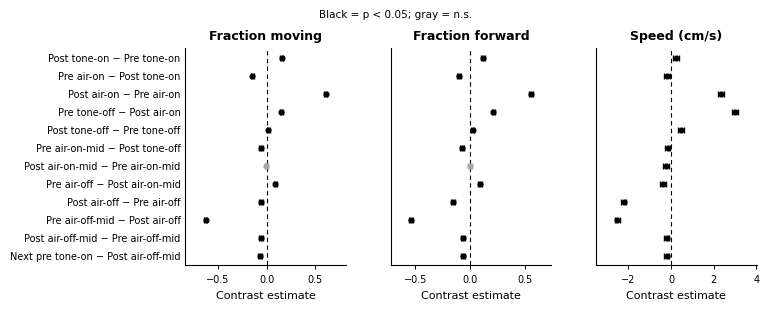

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Source dataframe
# ==================================================

tone_contrasts_df = tone_air_contrasts_R.copy()

# ==================================================
# Keep primary locomotor outcomes only
# ==================================================

primary_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

outcome_labels = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

tone_contrasts_df = tone_contrasts_df[
    tone_contrasts_df["outcome"].isin(primary_outcomes)
].copy()

# ==================================================
# Robust column cleanup
# ==================================================

for col in ["estimate", "SE", "p.value"]:
    if col in tone_contrasts_df.columns:
        tone_contrasts_df[col] = pd.to_numeric(tone_contrasts_df[col], errors="coerce")

# Create CI columns if they are missing
if "lower.CL" not in tone_contrasts_df.columns:
    if "asymp.LCL" in tone_contrasts_df.columns:
        tone_contrasts_df["lower.CL"] = tone_contrasts_df["asymp.LCL"]
    elif "lower" in tone_contrasts_df.columns:
        tone_contrasts_df["lower.CL"] = tone_contrasts_df["lower"]
    else:
        tone_contrasts_df["lower.CL"] = (
            tone_contrasts_df["estimate"] - 1.96 * tone_contrasts_df["SE"]
        )

if "upper.CL" not in tone_contrasts_df.columns:
    if "asymp.UCL" in tone_contrasts_df.columns:
        tone_contrasts_df["upper.CL"] = tone_contrasts_df["asymp.UCL"]
    elif "upper" in tone_contrasts_df.columns:
        tone_contrasts_df["upper.CL"] = tone_contrasts_df["upper"]
    else:
        tone_contrasts_df["upper.CL"] = (
            tone_contrasts_df["estimate"] + 1.96 * tone_contrasts_df["SE"]
        )

tone_contrasts_df["lower.CL"] = pd.to_numeric(tone_contrasts_df["lower.CL"], errors="coerce")
tone_contrasts_df["upper.CL"] = pd.to_numeric(tone_contrasts_df["upper.CL"], errors="coerce")

# ==================================================
# Contrast order and labels
# ==================================================

contrast_order = [
    "tone_onset_transition",
    "tone_to_air_anticipatory_interval",
    "air_onset_transition",
    "early_air_on_to_tone_offset",
    "tone_offset_transition",
    "post_tone_offset_air_on_progression",
    "air_on_mid_transition",
    "late_air_on_progression",
    "air_offset_transition",
    "early_air_off_recovery",
    "air_off_mid_transition",
    "late_air_off_recovery_to_next_baseline",
]

contrast_labels = {
    "tone_onset_transition": "Post tone-on − Pre tone-on",
    "tone_to_air_anticipatory_interval": "Pre air-on − Post tone-on",
    "air_onset_transition": "Post air-on − Pre air-on",
    "early_air_on_to_tone_offset": "Pre tone-off − Post air-on",
    "tone_offset_transition": "Post tone-off − Pre tone-off",
    "post_tone_offset_air_on_progression": "Pre air-on-mid − Post tone-off",
    "air_on_mid_transition": "Post air-on-mid − Pre air-on-mid",
    "late_air_on_progression": "Pre air-off − Post air-on-mid",
    "air_offset_transition": "Post air-off − Pre air-off",
    "early_air_off_recovery": "Pre air-off-mid − Post air-off",
    "air_off_mid_transition": "Post air-off-mid − Pre air-off-mid",
    "late_air_off_recovery_to_next_baseline": "Next pre tone-on − Post air-off-mid",
}

# Keep only contrasts that exist in table
contrast_order = [
    c for c in contrast_order
    if c in tone_contrasts_df["contrast"].astype(str).unique()
]

tone_contrasts_df["contrast"] = pd.Categorical(
    tone_contrasts_df["contrast"].astype(str),
    categories=contrast_order,
    ordered=True
)

tone_contrasts_df["contrast_label"] = tone_contrasts_df["contrast"].astype(str).map(contrast_labels)

# Reverse order for plotting top-to-bottom
plot_order = contrast_order[::-1]
plot_labels = [contrast_labels[c] for c in plot_order]

# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(8.4, 3.2),
    sharey=True
)

y_pos = np.arange(len(plot_order))

for ax_i, (ax, outcome) in enumerate(zip(axes, primary_outcomes)):

    sub = tone_contrasts_df[
        tone_contrasts_df["outcome"] == outcome
    ].copy()

    sub = (
        sub.set_index("contrast")
        .reindex(plot_order)
        .reset_index()
    )

    estimates = sub["estimate"].astype(float).to_numpy()
    lower = sub["lower.CL"].astype(float).to_numpy()
    upper = sub["upper.CL"].astype(float).to_numpy()
    pvals = sub["p.value"].astype(float).to_numpy()

    sig = pvals < 0.05

    for i in range(len(sub)):

        color_i = "black" if sig[i] else "0.65"

        ax.errorbar(
            estimates[i],
            y_pos[i],
            xerr=np.array([
                [estimates[i] - lower[i]],
                [upper[i] - estimates[i]]
            ]),
            fmt="o",
            color=color_i,
            ecolor=color_i,
            elinewidth=0.9,
            capsize=2.3,
            markersize=3.4,
            zorder=3
        )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        dashes=(4, 3),
        zorder=1
    )

    ax.set_title(
        outcome_labels[outcome],
        fontsize=9,
        fontweight="bold",
        pad=6
    )

    ax.set_xlabel(
        "Contrast estimate",
        fontsize=8
    )

    ax.tick_params(
        axis="x",
        labelsize=7,
        width=0.7,
        length=3
    )

    ax.tick_params(
        axis="y",
        width=0.7,
        length=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Only first panel gets the contrast labels
    if ax_i == 0:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(plot_labels, fontsize=7)
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)

    # Add x padding separately for each outcome
    finite_vals = np.concatenate([
        lower[np.isfinite(lower)],
        upper[np.isfinite(upper)]
    ])

    if len(finite_vals) > 0:
        xmin = np.nanmin(finite_vals)
        xmax = np.nanmax(finite_vals)
    else:
        xmin, xmax = -1, 1

    xrng = xmax - xmin if xmax > xmin else 1
    ax.set_xlim(
        xmin - 0.15 * xrng,
        xmax + 0.15 * xrng
    )

# Figure-level note instead of overlapping text inside panel
fig.text(
    0.55,
    0.98,
    "Black = p < 0.05; gray = n.s.",
    ha="center",
    va="top",
    fontsize=7.5
)

fig.subplots_adjust(
    left=0.30,
    right=0.98,
    top=0.86,
    bottom=0.18,
    wspace=0.28
)

# ==================================================
# Save
# ==================================================

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig_tone_air_planned_contrasts_primary_measures.pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     fig_dir / "Fig_tone_air_planned_contrasts_primary_measures.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

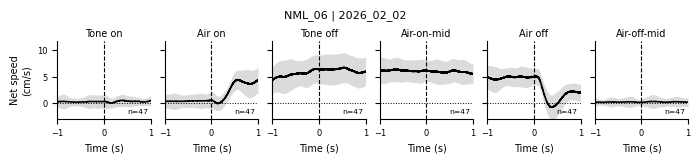

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_raw_net_speed_traces_tone_air_cycle_one_animal(
    epoch_matrix_df,
    animal,
    phase="tone_air_training",
    date=None,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=False,
    fig_dir=None,
    save_prefix="Fig_tone_air_cycle_raw_net_speed_one_animal",
):
    """
    Plot raw net-speed traces around tone-air-cycle anchors for one animal/day.

    Panels:
      1. tone_on
      2. air_on
      3. tone_off
      4. air_on_mid
      5. air_off
      6. air_off_mid

    Gray lines = individual events/trials
    Black line = mean
    Gray shaded region = mean ± SD
    """

    # --------------------------------------------------
    # Anchor order and labels
    # --------------------------------------------------

    anchor_order = [
        "tone_on",
        "air_on",
        "tone_off",
        "air_on_mid",
        "air_off",
        "air_off_mid",
    ]

    anchor_labels = {
        "tone_on": "Tone on",
        "air_on": "Air on",
        "tone_off": "Tone off",
        "air_on_mid": "Air-on-mid",
        "air_off": "Air off",
        "air_off_mid": "Air-off-mid",
    }

    # --------------------------------------------------
    # Select rows
    # --------------------------------------------------

    sub_all = epoch_matrix_df[
        (epoch_matrix_df["animal"] == animal) &
        (epoch_matrix_df["phase"] == phase) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if sub_all.empty:
        print(f"No rows found for animal={animal}, phase={phase}, anchors={anchor_order}")
        print("Available phases:")
        print(sorted(epoch_matrix_df["phase"].dropna().unique()))
        print("Available anchors for this animal/phase:")
        display(
            epoch_matrix_df[
                (epoch_matrix_df["animal"] == animal) &
                (epoch_matrix_df["phase"] == phase)
            ]["anchor_name"].value_counts()
        )
        return None

    if date is None:
        dates = sorted(sub_all["date"].dropna().unique())
        if len(dates) == 0:
            print("No date found.")
            return None
        date = dates[0]
        if len(dates) > 1:
            print("More than one date found. Using first:", date)

    sub_all = sub_all[sub_all["date"] == date].copy()

    if sub_all.empty:
        print(f"No rows left after filtering date={date}.")
        return None

    # --------------------------------------------------
    # Load raw speed data once
    # --------------------------------------------------

    b = pdio.load_behavior_h5(
        animal,
        date,
        keys=[speed_key, "fs"]
    )

    speed = np.asarray(b[speed_key]).reshape(-1)
    fs = float(np.asarray(b["fs"]).squeeze())

    n_pre = int(round(pre_s * fs))
    n_post = int(round(post_s * fs))
    expected_n = n_pre + n_post

    t = np.arange(-n_pre, n_post) / fs

    # --------------------------------------------------
    # Extract traces for each anchor
    # --------------------------------------------------

    traces_by_anchor = {}

    for anchor_name in anchor_order:

        sub = sub_all[sub_all["anchor_name"] == anchor_name].copy()

        if sub.empty:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))
            continue

        anchor_events = (
            sub[
                [
                    "animal",
                    "date",
                    "phase",
                    "event_number",
                    "anchor_name",
                    "anchor_time_s",
                ]
            ]
            .drop_duplicates()
            .sort_values("event_number")
            .reset_index(drop=True)
        )

        if max_traces is not None:
            anchor_events = anchor_events.iloc[:max_traces].copy()

        traces = []

        for _, ev in anchor_events.iterrows():

            anchor_time = ev["anchor_time_s"]

            if not np.isfinite(anchor_time):
                continue

            anchor_idx = int(round(anchor_time * fs))
            start_idx = anchor_idx - n_pre
            end_idx = anchor_idx + n_post

            if start_idx < 0 or end_idx > len(speed):
                continue

            trace = speed[start_idx:end_idx]

            if len(trace) == expected_n:
                traces.append(trace)

        if len(traces) > 0:
            traces_by_anchor[anchor_name] = np.vstack(traces)
        else:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))

    # --------------------------------------------------
    # Common y-limits
    # --------------------------------------------------

    all_valid_traces = [
        tr for tr in traces_by_anchor.values()
        if tr.shape[0] > 0
    ]

    if len(all_valid_traces) == 0:
        print("No valid traces extracted for any anchor.")
        return None

    all_traces = np.vstack(all_valid_traces)

    y_low, y_high = np.nanpercentile(all_traces, [1, 99])
    y_pad = 0.10 * (y_high - y_low)
    y_lim = (y_low - y_pad, y_high + y_pad)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        6,
        figsize=(7, 1.5),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        traces = traces_by_anchor[anchor_name]

        if traces.shape[0] == 0:
            ax.text(
                0.5,
                0.5,
                "No traces",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=7
            )
            ax.set_title(anchor_labels[anchor_name], fontsize=7)
            continue

        mean_trace = np.nanmean(traces, axis=0)
        std_trace = np.nanstd(traces, axis=0)

        if show_individual_traces:
            for tr in traces:
                ax.plot(
                    t,
                    tr,
                    color="0.75",
                    linewidth=0.35,
                    alpha=0.35
                )

        ax.fill_between(
            t,
            mean_trace - std_trace,
            mean_trace + std_trace,
            color="0.80",
            alpha=0.7,
            linewidth=0
        )

        ax.plot(
            t,
            mean_trace,
            color="black",
            linewidth=1.2
        )

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.8
        )

        ax.axhline(
            0,
            color="black",
            linestyle=":",
            linewidth=0.7
        )

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)

        ax.text(
            0.97,
            0.05,
            f"n={traces.shape[0]}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=5.5
        )

        ax.set_xlim(-pre_s, post_s)
        ax.set_ylim(y_lim)

        ax.tick_params(axis="both", labelsize=6)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    for ax in axes:
        ax.set_xlabel("Time (s)", fontsize=7)

    fig.suptitle(
        f"{animal} | {date}",
        fontsize=8,
        y=0.99
    )

    fig.tight_layout(pad=0.35, w_pad=0.4)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

        fname_base = f"{save_prefix}_{animal}_{phase}_{date}"

        fig.savefig(
            fig_dir / f"{fname_base}.pdf",
            bbox_inches="tight"
        )

        fig.savefig(
            fig_dir / f"{fname_base}.png",
            dpi=600,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "traces_by_anchor": traces_by_anchor,
        "time": t,
        "animal": animal,
        "date": date,
        "phase": phase,
        "speed_key": speed_key,
    }

out_tone = plot_raw_net_speed_traces_tone_air_cycle_one_animal(
    epoch_matrix_df=encoder_epoch_df,
    animal="NML_06",
    phase="tone_air_training",
    date="2026_02_02",
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=False,
    fig_dir=fig_dir_str,
)

,animal,n_sessions_tone_on,n_sessions_air_on,n_sessions_tone_off,n_sessions_air_on_mid,n_sessions_air_off,n_sessions_air_off_mid
0,NML_04,10,10,10,10,10,10
1,NML_05,10,10,10,10,10,10
2,NML_06,10,10,10,10,10,10
3,NML_07,10,10,10,10,10,10
4,NML_08,10,10,10,10,10,10


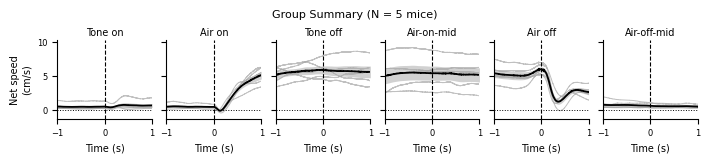

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def detect_anchor_order_for_phase_extended(epoch_matrix_df, phase):
    available = sorted(
        epoch_matrix_df.loc[
            epoch_matrix_df["phase"].astype(str) == str(phase),
            "anchor_name"
        ].dropna().unique()
    )

    candidate_orders = [
    # Tone-air-training phase FIRST
    ["tone_on", "air_on", "tone_off", "air_on_mid", "air_off", "air_off_mid"],

    # Repeated exposure / LED phase
    ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"],
    ["led_on", "led_on_mid", "led_off", "led_off_mid"],

    # Air-training phase
    ["air_on", "air_on_mid", "air_off", "air_off_mid"],
    ["air_onset", "air_on_mid", "air_offset", "air_off_mid"],
]

    for cand in candidate_orders:
        if all(a in available for a in cand):
            return cand

    print("Available anchors:")
    print(available)
    raise ValueError("Could not detect anchor names automatically.")


def plot_group_raw_net_speed_around_phase_anchors(
    epoch_matrix_df,
    phase="tone_air_training",
    animals=None,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    max_traces_per_session_anchor=None,
    show_individual_animals=True,
    fig_dir=None,
    save_prefix="Fig_group_raw_net_speed_phase_anchors",
):
    """
    Group raw net-speed traces around phase-specific timing anchors.

    For tone_air_training, anchors are:
      tone_on, air_on, tone_off, air_on_mid, air_off, air_off_mid

    Averaging hierarchy:
      event traces -> session mean -> animal mean -> group mean ± SEM
    """

    # --------------------------------------------------
    # Output folder
    # --------------------------------------------------

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # Anchor setup
    # --------------------------------------------------

    anchor_order = detect_anchor_order_for_phase_extended(epoch_matrix_df, phase)

    anchor_labels = {
        "LED_on": "LED on",
        "LED_on_mid": "LED-on-mid",
        "LED_off": "LED off",
        "LED_off_mid": "LED-off-mid",
        "led_on": "LED on",
        "led_on_mid": "LED-on-mid",
        "led_off": "LED off",
        "led_off_mid": "LED-off-mid",
        "air_on": "Air on",
        "air_on_mid": "Air-on-mid",
        "air_off": "Air off",
        "air_off_mid": "Air-off-mid",
        "air_onset": "Air on",
        "air_offset": "Air off",
        "tone_on": "Tone on",
        "tone_off": "Tone off",
    }

    # --------------------------------------------------
    # Filter dataframe
    # --------------------------------------------------

    df = epoch_matrix_df[
        (epoch_matrix_df["phase"].astype(str) == str(phase)) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if animals is None:
        animals = sorted(df["animal"].dropna().unique())
    else:
        animals = list(animals)
        df = df[df["animal"].isin(animals)].copy()

    if max_session_time_min is not None:
        df = df[df["anchor_time_s"] <= max_session_time_min * 60].copy()

    if df.empty:
        raise ValueError("No rows left after filtering.")

    # --------------------------------------------------
    # Extract traces animal by animal
    # --------------------------------------------------

    animal_mean_traces = {a: [] for a in anchor_order}
    animal_ids_used = {a: [] for a in anchor_order}
    session_counts = []

    for animal in animals:

        df_animal = df[df["animal"] == animal].copy()

        if df_animal.empty:
            continue

        session_mean_by_anchor = {a: [] for a in anchor_order}

        for date, df_session in df_animal.groupby("date", observed=True):

            try:
                b = pdio.load_behavior_h5(
                    animal,
                    date,
                    keys=[speed_key, "fs"]
                )
            except Exception as e:
                print(f"Skipping {animal} {date}: could not load H5. Error: {e}")
                continue

            speed = np.asarray(b[speed_key]).reshape(-1)
            fs = float(np.asarray(b["fs"]).squeeze())

            n_pre = int(round(pre_s * fs))
            n_post = int(round(post_s * fs))
            expected_n = n_pre + n_post
            rel_t = np.arange(-n_pre, n_post) / fs

            for anchor_name in anchor_order:

                sub = df_session[df_session["anchor_name"] == anchor_name].copy()

                if sub.empty:
                    continue

                anchor_events = (
                    sub[
                        [
                            "event_number",
                            "anchor_name",
                            "anchor_time_s",
                        ]
                    ]
                    .drop_duplicates()
                    .sort_values("event_number")
                    .reset_index(drop=True)
                )

                if max_traces_per_session_anchor is not None:
                    anchor_events = anchor_events.iloc[:max_traces_per_session_anchor].copy()

                traces = []

                for _, ev in anchor_events.iterrows():

                    anchor_time = ev["anchor_time_s"]

                    if not np.isfinite(anchor_time):
                        continue

                    anchor_idx = int(round(anchor_time * fs))
                    start_idx = anchor_idx - n_pre
                    end_idx = anchor_idx + n_post

                    if start_idx < 0 or end_idx > len(speed):
                        continue

                    trace = speed[start_idx:end_idx]

                    if len(trace) == expected_n:
                        traces.append(trace)

                if len(traces) > 0:
                    traces = np.vstack(traces)
                    session_mean = np.nanmean(traces, axis=0)
                    session_mean_by_anchor[anchor_name].append(session_mean)

        # Average session means within animal
        for anchor_name in anchor_order:

            if len(session_mean_by_anchor[anchor_name]) == 0:
                continue

            session_means = np.vstack(session_mean_by_anchor[anchor_name])
            animal_mean = np.nanmean(session_means, axis=0)

            animal_mean_traces[anchor_name].append(animal_mean)
            animal_ids_used[anchor_name].append(animal)

        session_counts.append({
            "animal": animal,
            **{
                f"n_sessions_{anchor_name}": len(session_mean_by_anchor[anchor_name])
                for anchor_name in anchor_order
            }
        })

    session_counts_df = pd.DataFrame(session_counts)
    display(session_counts_df)

    # --------------------------------------------------
    # Group mean ± SEM
    # --------------------------------------------------

    group_summary = {}

    for anchor_name in anchor_order:

        if len(animal_mean_traces[anchor_name]) == 0:
            group_summary[anchor_name] = None
            continue

        arr = np.vstack(animal_mean_traces[anchor_name])

        group_mean = np.nanmean(arr, axis=0)
        group_sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])

        group_summary[anchor_name] = {
            "animal_mean_traces": arr,
            "group_mean": group_mean,
            "group_sem": group_sem,
            "n_animals": arr.shape[0],
            "animal_ids": animal_ids_used[anchor_name],
        }

    # --------------------------------------------------
    # Common y-limits
    # --------------------------------------------------

    all_group_values = []

    for anchor_name in anchor_order:
        s = group_summary[anchor_name]
        if s is None:
            continue
        all_group_values.append(s["animal_mean_traces"])

    all_group_values = np.vstack(all_group_values)

    y_low, y_high = np.nanpercentile(all_group_values, [1, 99])
    y_pad = 0.15 * (y_high - y_low)
    y_lim = (y_low - y_pad, y_high + y_pad)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    n_anchors = len(anchor_order)

    fig, axes = plt.subplots(
        1,
        n_anchors,
        figsize=(7 if n_anchors == 6 else 3.5, 1.5),
        sharex=True,
        sharey=True
    )

    if n_anchors == 1:
        axes = [axes]

    for ax, anchor_name in zip(axes, anchor_order):

        s = group_summary[anchor_name]

        if s is None:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=7
            )
            continue

        animal_arr = s["animal_mean_traces"]
        group_mean = s["group_mean"]
        group_sem = s["group_sem"]

        if show_individual_animals:
            for tr in animal_arr:
                ax.plot(
                    rel_t,
                    tr,
                    color="0.65",
                    linewidth=0.7,
                    alpha=0.7
                )

        ax.fill_between(
            rel_t,
            group_mean - group_sem,
            group_mean + group_sem,
            color="0.80",
            linewidth=0,
            alpha=0.9
        )

        ax.plot(
            rel_t,
            group_mean,
            color="black",
            linewidth=1.3
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
        ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

        ax.set_title(
            anchor_labels.get(anchor_name, anchor_name),
            fontsize=7,
            pad=3
        )

        ax.set_xlabel("Time (s)", fontsize=7)
        ax.tick_params(axis="both", labelsize=6)
        ax.set_xlim(-pre_s, post_s)
        ax.set_ylim(y_lim)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    fig.suptitle(
        f"Group Summary (N = {len(animals)} mice)",
        fontsize=8,
        y=0.99
    )

    fig.tight_layout(pad=0.35, w_pad=0.4)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    if fig_dir is not None:
        fname = f"{save_prefix}_{phase}"

        fig.savefig(
            fig_dir / f"{fname}.pdf",
            bbox_inches="tight"
        )

        fig.savefig(
            fig_dir / f"{fname}.png",
            dpi=600,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "rel_t": rel_t,
        "group_summary": group_summary,
        "session_counts_df": session_counts_df,
        "anchor_order": anchor_order,
    }


out_group_tone = plot_group_raw_net_speed_around_phase_anchors(
    epoch_matrix_df=encoder_epoch_df,
    phase="tone_air_training",
    animals=None,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    show_individual_animals=True,
    fig_dir=fig_dir_str,
    save_prefix="Fig_group_raw_net_speed_tone_air_anchors",
)

,outcome,tone_air_cycle_epoch,cycle_session_10m_c.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value,beta,lower.CL,upper.CL
0,frac_moving,pre_tone_on,-0.003921,0.011427,inf,-0.026318,0.018476,-0.343128,7.315024e-01,-0.003921,-0.026318,0.018476
1,frac_moving,post_tone_on,-0.003799,0.011427,inf,-0.026196,0.018598,-0.332438,7.395587e-01,-0.003799,-0.026196,0.018598
2,frac_moving,pre_air_on,-0.003423,0.011427,inf,-0.025819,0.018974,-0.299523,7.645410e-01,-0.003423,-0.025819,0.018974
3,frac_moving,post_air_on,0.012316,0.011427,inf,-0.010081,0.034712,1.077750,2.811453e-01,0.012316,-0.010081,0.034712
4,frac_moving,pre_tone_off,-0.005061,0.011427,inf,-0.027458,0.017335,-0.442923,6.578213e-01,-0.005061,-0.027458,0.017335
5,frac_moving,post_tone_off,-0.014645,0.011427,inf,-0.037042,0.007752,-1.281614,1.999781e-01,-0.014645,-0.037042,0.007752
6,frac_moving,pre_air_on_mid,-0.042377,0.011427,inf,-0.064774,-0.019980,-3.708449,2.085323e-04,-0.042377,-0.064774,-0.019980
7,frac_moving,post_air_on_mid,-0.043796,0.011427,inf,-0.066193,-0.021399,-3.832615,1.267881e-04,-0.043796,-0.066193,-0.021399
8,frac_moving,pre_air_off,-0.009710,0.011427,inf,-0.032107,0.012687,-0.849712,3.954851e-01,-0.009710,-0.032107,0.012687
9,frac_moving,post_air_off,-0.005574,0.011427,inf,-0.027971,0.016823,-0.487786,6.257013e-01,-0.005574,-0.027971,0.016823


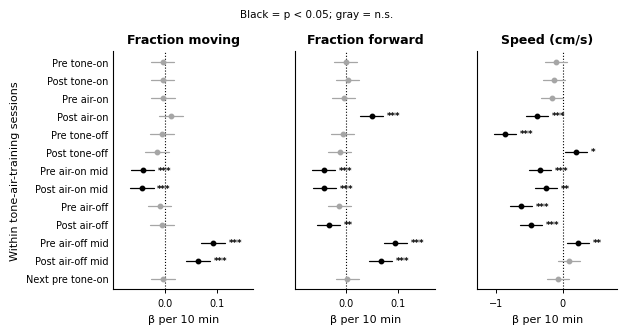

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Source dataframe: within-session-time trends
# ==================================================

plot_df = tone_air_session_time_trends_R.copy()

# ==================================================
# Keep primary locomotor outcomes only
# ==================================================

primary_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

outcome_labels = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

plot_df = plot_df[
    plot_df["outcome"].isin(primary_outcomes)
].copy()

# ==================================================
# Standardize column names
# ==================================================

# emtrends usually gives this column name
if "beta" not in plot_df.columns:
    if "cycle_session_10m_c.trend" in plot_df.columns:
        plot_df["beta"] = plot_df["cycle_session_10m_c.trend"]
    elif "session_time_10m_c.trend" in plot_df.columns:
        plot_df["beta"] = plot_df["session_time_10m_c.trend"]
    else:
        raise KeyError("Could not find trend column. Check plot_df.columns.")

# Standardize CI columns
if "lower.CL" not in plot_df.columns:
    if "asymp.LCL" in plot_df.columns:
        plot_df["lower.CL"] = plot_df["asymp.LCL"]
    elif "lower" in plot_df.columns:
        plot_df["lower.CL"] = plot_df["lower"]
    else:
        plot_df["lower.CL"] = plot_df["beta"] - 1.96 * plot_df["SE"]

if "upper.CL" not in plot_df.columns:
    if "asymp.UCL" in plot_df.columns:
        plot_df["upper.CL"] = plot_df["asymp.UCL"]
    elif "upper" in plot_df.columns:
        plot_df["upper.CL"] = plot_df["upper"]
    else:
        plot_df["upper.CL"] = plot_df["beta"] + 1.96 * plot_df["SE"]

for col in ["beta", "SE", "lower.CL", "upper.CL", "p.value"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# ==================================================
# Epoch order and labels
# ==================================================

epoch_order = [
    "pre_tone_on",
    "post_tone_on",
    "pre_air_on",
    "post_air_on",
    "pre_tone_off",
    "post_tone_off",
    "pre_air_on_mid",
    "post_air_on_mid",
    "pre_air_off",
    "post_air_off",
    "pre_air_off_mid",
    "post_air_off_mid",
    "pre_tone_on_next",
]

epoch_labels = {
    "pre_tone_on": "Pre tone-on",
    "post_tone_on": "Post tone-on",
    "pre_air_on": "Pre air-on",
    "post_air_on": "Post air-on",
    "pre_tone_off": "Pre tone-off",
    "post_tone_off": "Post tone-off",
    "pre_air_on_mid": "Pre air-on mid",
    "post_air_on_mid": "Post air-on mid",
    "pre_air_off": "Pre air-off",
    "post_air_off": "Post air-off",
    "pre_air_off_mid": "Pre air-off mid",
    "post_air_off_mid": "Post air-off mid",
    "pre_tone_on_next": "Next pre tone-on",
}

epoch_order = [
    e for e in epoch_order
    if e in plot_df["tone_air_cycle_epoch"].astype(str).unique()
]

plot_df["tone_air_cycle_epoch"] = pd.Categorical(
    plot_df["tone_air_cycle_epoch"].astype(str),
    categories=epoch_order,
    ordered=True
)

plot_df["outcome"] = pd.Categorical(
    plot_df["outcome"],
    categories=primary_outcomes,
    ordered=True
)

plot_df = plot_df.sort_values(
    ["outcome", "tone_air_cycle_epoch"]
).reset_index(drop=True)

display(plot_df)

# ==================================================
# Helper
# ==================================================

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(7, 3.5),
    sharey=True
)

# reverse so first epoch appears at top
plot_order = epoch_order[::-1]
plot_labels = [epoch_labels.get(e, e) for e in plot_order]
y_pos = np.arange(len(plot_order))

for ax_i, (ax, outcome) in enumerate(zip(axes, primary_outcomes)):

    sub = plot_df[
        plot_df["outcome"] == outcome
    ].copy()

    sub = (
        sub.set_index("tone_air_cycle_epoch")
        .reindex(plot_order)
        .reset_index()
    )

    beta = sub["beta"].astype(float).to_numpy()
    lo = sub["lower.CL"].astype(float).to_numpy()
    hi = sub["upper.CL"].astype(float).to_numpy()
    pvals = sub["p.value"].astype(float).to_numpy()

    sig = pvals < 0.05

    x_min = np.nanmin(lo)
    x_max = np.nanmax(hi)
    x_rng = x_max - x_min if x_max > x_min else 1

    for i in range(len(sub)):

        color_i = "black" if sig[i] else "0.65"

        ax.plot(
            [lo[i], hi[i]],
            [y_pos[i], y_pos[i]],
            color=color_i,
            linewidth=0.9,
            solid_capstyle="round",
            zorder=2
        )

        ax.plot(
            beta[i],
            y_pos[i],
            marker="o",
            markersize=3.2,
            color=color_i,
            zorder=3
        )

        stars = p_to_stars(pvals[i])
        if stars:
            ax.text(
                hi[i] + 0.04 * x_rng,
                y_pos[i],
                stars,
                va="center",
                ha="left",
                fontsize=6.3,
                fontweight="bold"
            )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=0.8,
        zorder=1
    )

    ax.set_title(
        outcome_labels[outcome],
        fontsize=9,
        fontweight="bold",
        pad=6
    )

    ax.set_xlabel(
        "β per 10 min",
        fontsize=8
    )

    ax.tick_params(
        axis="x",
        labelsize=7,
        width=0.7,
        length=3
    )

    ax.tick_params(
        axis="y",
        width=0.7,
        length=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax_i == 0:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(plot_labels, fontsize=7)
        ax.set_ylabel("Within tone-air-training sessions", fontsize=8)
    else:
        ax.tick_params(axis="y", left=False, labelleft=False)

    ax.set_xlim(
        x_min - 0.18 * x_rng,
        x_max + 0.30 * x_rng
    )

fig.text(
    0.55,
    0.98,
    "Black = p < 0.05; gray = n.s.",
    ha="center",
    va="top",
    fontsize=7.5
)

fig.subplots_adjust(
    left=0.26,
    right=0.98,
    top=0.86,
    bottom=0.18,
    wspace=0.30
)

# ==================================================
# Save
# ==================================================

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig_tone_air_within_session_epoch_trends_primary_measures.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "Fig_tone_air_within_session_epoch_trends_primary_measures.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()